# Tutorial: Critic-Reflection Pattern with **Open Source AgentGrid** SDKs

- Author: Shridhar Kini
- To Securely Run: `jupyter notebook password` to generate onetime password for secure access
- To Run at root directory of the repo: `jupyter notebook --allow-root --port 9999 --ip=0.0.0.0` 
- To Clear Outputs: Use `jupyter nbconvert --clear-output --inplace 7_CriticReflection_Pattern.ipynb` 

This walkthrough demonstrates how to build and orchestrate a `Critic-Reflection agentic pipeline` using the **AgentGrid SDKs**. We focus on the **Software Architecture Debate**, where a Software Agent proposes designs and a Senior Architect Agent provides critical feedback and scores until a quality threshold is met.

## Resource Links
To Know more about the Open Source AgentGrid SDKs, please refer to the [AgentGrid Github](https://github.com/opencyber-space/AgentGr.id) or Resource [AgentGrid SDKs Documentation](https://resources.agentgr.id/) or (https://www.agentgr.id/) 

## Agentic Patterns Link
To know more about the Agentic Patterns, please refer to the [Agentic Patterns](https://www.anthropic.com/engineering/building-effective-agents) And [Video](https://www.youtube.com/watch?v=e2zIr_2JMbE) And [Blog](https://www.mattprd.com/p/the-complete-beginners-guide-to-autonomous-agents)

---

## 1. Agent LLM Interface: `agents_llm`

The `agents_llm` library provides a unified interface for model inference. This allows you to swap models (Qwen, Llama, etc.) without changing your agent's core logic. The models which are hosted in AIOS as blocks or 3rd party models like OpenAI/Gemini/etc also can be accessed via the `agents_llm` library.

---

## 2. Orchestration & Communication: `agents_sdk`

The `agents_sdk` framework handles the "lifecycle" and "social" aspects of an agent. It provides core data structures like `AgentTask` and `AgentResult`, and a `Context` object for peer-to-peer (`p2p_manager`), delegated (`delegator`), or direct (`direct`) communication.

---

## 3. Case Study: Software Architecture Debate (Critic-Reflection)

The **Critic-Reflection Pattern** involves one agent (the Reflector) generating content and another (the Critic) evaluating it. The Reflector then incorporates the feedback to improve the output in subsequent rounds.

### Architecture Debate Pipeline:
1. **Propose**: The `Software Agent` analyzes the user requirement and proposes a set of technical components.
2. **Parse**: The `Senior Architect Agent` parses the proposal into individual components for granular evaluation.
3. **Critique**: The `Senior Architect Agent` (Critic) evaluates each component using mathematical scrutiny and "crazy" probing (failure mode analysis).
4. **Score & Feedback**: The Critic assigns a `satisfaction_score`. If the score is `< 95`, it provides actionable feedback.
5. **Reflect**: The `Software Agent` receives the feedback and provides an updated, self-contained technical specification or defends the original design.
6. **Finalize**: The loop continues (up to 3 rounds) for each component until approval. Finally, the Architect synthesizes the full report.

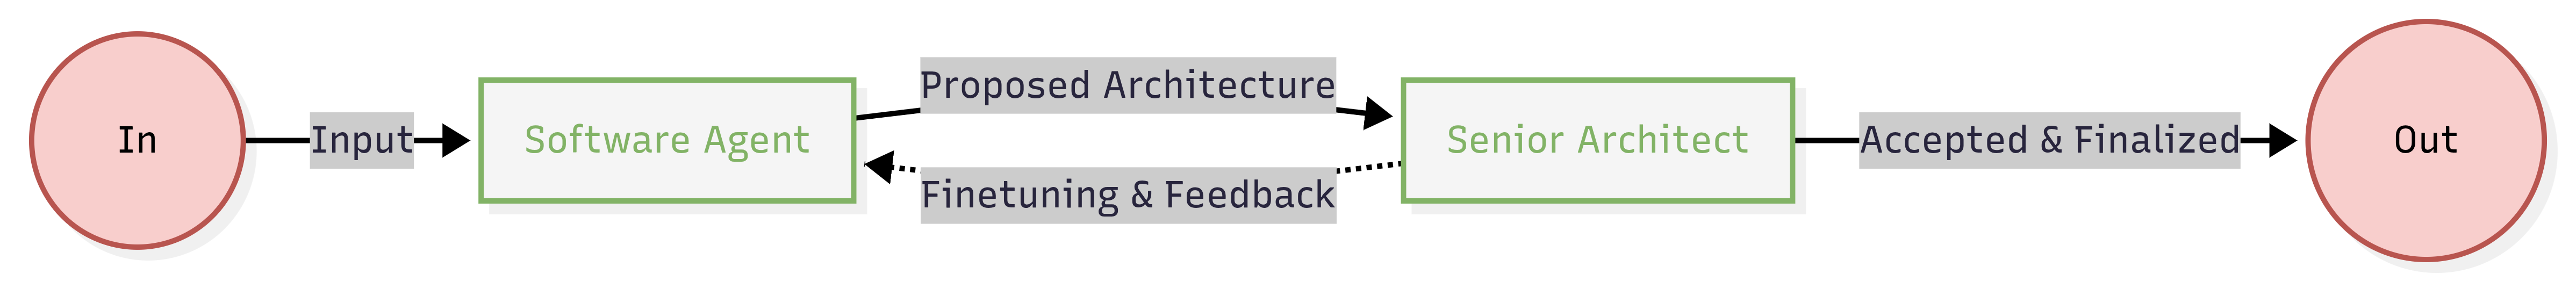

### Critic-Reflection DSPy Signatures
The pattern is driven by specialized DSPy signatures that define the roles of the Reflector and the Critic.

In [ ]:
# From agent_debateragents_seniorarchitectagent.py
class ComponentEvaluatorSignature(dspy.Signature):
    """
    Evaluate a component with QUANTITATIVE SCRUTINY and CREATIVE PROBING.
    Assign a 'satisfaction_score' (0-100). 
    Only approve if satisfaction_score >= 95.
    """
    user_request = dspy.InputField()
    current_component_details = dspy.InputField()
    
    is_approved = dspy.OutputField(type=bool)
    satisfaction_score = dspy.OutputField()
    feedback = dspy.OutputField() # Required if score < 95
    reasoning = dspy.OutputField()

# From agent_debateragents_softwareagent.py
class ComponentDiscussionSignature(dspy.Signature):
    """
    Software Architect Generator in refinement mode.
    TECHNICAL ASSERTIVENESS: Provide specific technical SPECIFICATIONS.
    QUANTITATIVE PRECISION: provide load, RAM, CPU, Disk, and Latency estimates.
    """
    feedback = dspy.InputField()
    component_details = dspy.OutputField() # The COMPLETELY UPDATED technical specification

### Agent Roles & Source Files

| Agent Role | Source File | Responsibilities |
| :--- | :--- | :--- |
| **Software Agent (Reflector)** | [`agent_debateragents_softwareagent.py`](agent_codes/agent_debateragents_softwareagent.py) | Generates initial plans and iteratively refines them based on critique. |
| **Senior Architect (Critic)** | [`agent_debateragents_seniorarchitectagent.py`](agent_codes/agent_debateragents_seniorarchitectagent.py) | Evaluates plans using rigorous technical standards and assigns approval scores. |

---

## 4. Execution Pipeline

1. **Agent Registration**: Register all RFC agents in the cluster.
   - Script: [register-agents.sh](../../agents_registration/7_CriticReflection_SoftwareArchitect_agents/register-agents.sh)
2. **Deployment**: Spin up containers for the RFC evaluation flow.
   - Script: [deploy-agents.sh](../../agents_registration/7_CriticReflection_SoftwareArchitect_agents/deploy-agents.sh)
3. **Triggering the Flow**: Send the initial RFC text to the **Summarizer**.
   - Script: [inference_request.sh](../../agents_registration/7_CriticReflection_SoftwareArchitect_agents/inference_request.sh)
4. **All in One**: Run [all.bash](../../agents_registration/7_CriticReflection_SoftwareArchitect_agents/all.bash) to do 
    - `1. Remove agents if already running` 
    - `2. Unregister agent` 
    - `3. Register agent` 
    - `4. Deploy agents again` 

#### Run all.bash to setup the Critic-Reflection Flow

In [ ]:
%%bash
cd ../../agents_registration/7_CriticReflection_SoftwareArchitect_agents
bash all.bash

#### Run Streamlit app for watching the agents in action

In [ ]:
%%bash --bg --proc my_bg_process
cd ../../agents_registration/7_CriticReflection_SoftwareArchitect_agents
source ../../agent_codes/venv/bin/activate
bash run_streamlit_app.bash

#### Open `http:{IP}:8501` in browser for streamlit app

#### Check for pods in agents namespace

In [ ]:
%%bash
kubectl get pods -n agents

##### Check Containers in a Pod

In [ ]:
%%bash 
kubectl get pod -n agents executor-software-agent-c788d5654-hrmxz -o jsonpath='{.spec.containers[*].name}'

#### Trigger the First agent (Software Agent)

In [ ]:
%%bash
echo "$PWD"
cd ../../agents_registration/7_CriticReflection_SoftwareArchitect_agents
echo "$PWD"
bash inference_request.sh

#### To Remove the Agent Pods

In [ ]:
%%bash
cd ../../agents_registration/7_CriticReflection_SoftwareArchitect_agents
bash remove-agents.sh

## Conclusion
The Critic-Reflection pattern ensures that outputs meet a high bar of technical excellence. By automating the "review-fix" loop, you can achieve complex technical goals with far greater reliability than a single-pass generation approach.